# 09 · MLOps Toolkit — the pipeline in production

The earlier notebooks *built* a model. This one shows the **MLOps** stages that
keep it running responsibly — each is a small module under `src/car_pricing/`.
Full plain-English guide: [`docs/MLOPS_GUIDE.md`](../docs/MLOPS_GUIDE.md).

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import pandas as pd, matplotlib.pyplot as plt
from car_pricing import (validation, tuning, tracking, explain,
                         registry, monitoring, drift, data)

## 1 · Data validation — a bouncer for the data

In [2]:
rep = validation.validate_dataframe(data.clean(data.load_raw()))
print(rep.summary())

Data validation on 19,820 rows: PASS
  [warning] 'km_driven' has 3 value(s) outside [0, 1000000]
  [warning] 'mileage' has 4 value(s) outside [0.0, 60.0]


## 2 · Hyperparameter tuning — search for better settings (logged to the tracker)

In [3]:
res = tuning.tune('LightGBM', n_iter=5)
print('best CV MAE:', res['best_cv_mae_lakhs'], 'Lakhs')
res['best_params']

best CV MAE: 0.702 Lakhs


{'learning_rate': 0.054944814261683496,
 'n_estimators': 570,
 'num_leaves': 121,
 'subsample': 0.9339073000818308}

## 3 · Experiment tracking — a lab notebook of runs (MLflow + JSONL)
Browse in a UI with `mlflow ui`. Here we just read the log back:

In [4]:
runs = tracking.load_runs()
runs.tail(3)

,run_name,time,param.lr,param.n,metric.cv_mae,param.model,param.n_iter,param.learning_rate,param.n_estimators,param.num_leaves,param.subsample,metric.cv_mae_lakhs
0,verify,2026-07-11T05:35:50,0.05,300.0,0.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,tune-LightGBM,2026-07-11T05:38:26,NaN,NaN,NaN,LightGBM,6.0,0.084098,613.0,36.0,0.702120,0.695327
2,tune-LightGBM,2026-07-11T05:47:44,NaN,NaN,NaN,LightGBM,5.0,0.054945,570.0,121.0,0.933907,0.701883


## 4 · Explainability — which features drive the price?

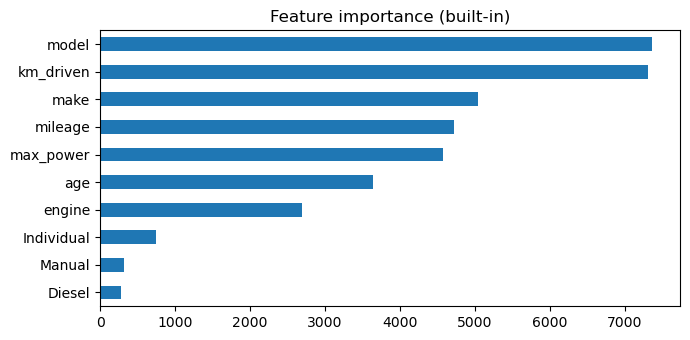

model        7365
km_driven    7308
make         5046
mileage      4715
max_power    4569
age          3636
dtype: int32

In [5]:
imp = explain.builtin_importances()
ax = imp.head(10)[::-1].plot.barh(figsize=(7,3.5), title='Feature importance (built-in)')
plt.tight_layout(); plt.show()
imp.head(6).round(3)

## 5 · Model versioning — register the current model so we can roll back

In [6]:
entry = registry.register(note='from notebook 09')
print('registered:', entry['version'], '| stage:', entry['stage'])
entry['metrics']

registered: v2-20260711-054745 | stage: staging


{'winner': 'LightGBM',
 'price_r2': 0.9568,
 'price_mae_lakhs': 0.664,
 'band_accuracy': 0.8582}

## 6 · Monitoring — log served predictions, measure live error once actuals arrive

In [7]:
for car, actual in [({'make':'MARUTI','model':'SWIFT VXI'}, 5.5),
                    ({'make':'BMW','model':'X5'}, 19.0)]:
    from car_pricing.predict import predict
    p = predict(car)['predicted_price_lakhs']
    monitoring.log_prediction(car, p, actual_lakhs=actual)
monitoring.live_metrics()

{'n_predictions': 3,
 'n_with_actual': 3,
 'live_mae_lakhs': 0.703,
 'kpi_breached': False}

## 7 · Drift detection — has new data drifted from training data?
We simulate 'this year's cars are 8 years older' and check:

In [8]:
df = data.clean(data.load_raw())
ref = df.sample(frac=0.5, random_state=1)
cur = df.sample(frac=0.5, random_state=2).copy(); cur['age'] = cur['age'] + 8
out = drift.detect_drift(ref, cur)
print('drift detected:', out['drift_detected'], '| features drifted:', out['n_drifted'])
out['report']

drift detected: True | features drifted: 1


,feature,psi,ks_pvalue,drift
0,km_driven,0.001,0.9327,False
1,mileage,0.001,0.9947,False
2,engine,0.001,0.5284,False
3,max_power,0.002,0.7411,False
4,age,10.055,0.0000,True


## 8 · CI / CD / CT, serving & governance — the rest

These are files, not cells:

- **CI / CD / CT:** `.github/workflows/ci.yml`, `cd.yml`, `ct.yml` — test on every
  push, build+publish the image on a release tag, retrain on a schedule/data change.
- **Serving:** `python -m car_pricing.serve` (Flask API) or `docker build . && docker run`.
- **Governance:** [`docs/GOVERNANCE.md`](../docs/GOVERNANCE.md) — the KPI gate,
  registry, lineage, model card, monitoring & rollback.

The whole loop: **validate → tune/train → KPI gate → register → serve → monitor →
drift? → retrain (CT)** — see [`docs/MLOPS_GUIDE.md`](../docs/MLOPS_GUIDE.md).